# Parameter Sweep Demo (MalthusJAX)
This notebook demonstrates how to run parameter sweeps (hyperparameter exploration)
using MalthusJAX's engine factory and adapters. It runs a small quick sweep,
saves results, and shows basic analysis and visualizations.

**Prerequisites:**
- Activate your environment (e.g., `conda activate GP_env`)
- Install dependencies (JAX, evosax, matplotlib, seaborn, joblib)

**Expected runtime:** quick sample runs complete in seconds; larger sweeps take minutes to hours.

In [1]:
# Environment setup and imports
import sys
from pathlib import Path
repo_root = Path("..").resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import json
import time
import itertools
import math

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

from joblib import Parallel, delayed

# JAX
import jax
import jax.random as jr

# MalthusJAX utilities
from scripts.parameter_sweep_two_engines import ParameterSweep
from scripts.analyze_sweep import SweepAnalyzer
from malthusjax.composer.engine_factory import build_engine, build_engine_from_catalog, GeneticEngineAdapter
from malthusjax.composer.catalog import OperatorCatalog
from malthusjax.core.fitness.real_evaluators import SphereConfig, SphereEvaluator

print("Imports OK. Repo root:", repo_root)


Imports OK. Repo root: /Users/leonardodicaterina/Documents/GitHub/MalthusJAX


In [2]:
# Inspect engine factory and create adapter from catalog operators
print(build_engine.__doc__[:400])

catalog = OperatorCatalog()
# Example: fetch operators from catalog
sel = catalog.get(f"tournament:num_selections=20,tournament_size=3")
cross = catalog.get("blend:alpha=0.5")
mut = catalog.get("gaussian:mutation_rate=0.1")

# Create a Sphere evaluator instance
sphere_eval = SphereEvaluator(SphereConfig(maximize=False))

# Build engine adapter directly (explicit instances)
adapter = build_engine(
    fitness_evaluator=sphere_eval,
    selection_op=sel,
    crossover_op=cross,
    mutation_op=mut,
    genome_type="real",
    pop_size=20,
    generations=10,
)

print("Adapter created:", type(adapter))
print("Genome config:", adapter.genome_config)


Build a GeneticEngine from catalog operators.
    Args:
        fitness_evaluator: Fitness evaluator instance
        selection_op: Selection operator instance
        crossover_op: Crossover operator instance
        mutation_op: Mutation operator instance
        genome_type: "real" or "binary"
        pop_size: Population size
        generations: Number of generations
        elitism: Number o
Adapter created: <class 'malthusjax.composer.engine_factory.GeneticEngineAdapter'>
Genome config: RealGenomeConfig(shape=(10,), bounds=(-5.0, 5.0), dtype='float32')


In [3]:
# Validate operator variables and repair if overwritten
from malthusjax.operators.base import BaseSelection, BaseCrossover, BaseMutation

specs = {
    'selection': 'tournament:num_selections=20,tournament_size=3',
    'crossover': 'blend:alpha=0.5',
    'mutation': 'gaussian:mutation_rate=0.1',
}

repaired = False
if not isinstance(sel, BaseSelection):
    print(f"sel has wrong type {type(sel)}; re-fetching from catalog using spec: {specs['selection']}")
    sel = catalog.get(specs['selection'])
    repaired = True
if not isinstance(cross, BaseCrossover):
    print(f"cross has wrong type {type(cross)}; re-fetching from catalog using spec: {specs['crossover']}")
    cross = catalog.get(specs['crossover'])
    repaired = True
if not isinstance(mut, BaseMutation):
    print(f"mut has wrong type {type(mut)}; re-fetching from catalog using spec: {specs['mutation']}")
    mut = catalog.get(specs['mutation'])
    repaired = True

if repaired:
    # Rebuild the adapter to ensure engine uses repaired operators
    adapter = build_engine(
        fitness_evaluator=sphere_eval,
        selection_op=sel,
        crossover_op=cross,
        mutation_op=mut,
        genome_type="real",
        pop_size=20,
        generations=10,
    )
    print("Adapter re-created with repaired operators.")

print('Current operator types:')
print('  selection ->', type(sel))
print('  crossover ->', type(cross))
print('  mutation  ->', type(mut))

Current operator types:
  selection -> <class 'malthusjax.operators.selection.tournament.TournamentSelection'>
  crossover -> <class 'malthusjax.operators.crossover.real.BlendCrossover'>
  mutation  -> <class 'malthusjax.operators.mutation.real.GaussianMutation'>


In [4]:
# Baseline single-run example
key = jr.PRNGKey(42)
result = adapter.run_once(key)

print("Run keys:", result.keys())
print("Summary:", result['summary'])
print("Last history item sample:", result['history'][-1] if result['history'] else None)


Run keys: dict_keys(['history', 'summary', 'timings'])
Summary: {'best_fitness': -2.090304374694824, 'final_generation': 10, 'total_evaluations': 200, 'stagnation_counter': 0}
Last history item sample: {'generation': 10, 'best_fitness': -2.090304374694824, 'mean_fitness': -5.622501373291016, 'std_fitness': 0.0}


In [5]:
# Define parameter grid for sweep
from itertools import product

param_grid = list(product(
    [20, 30],  # pop_size
    [10, 20],  # generations
    [0, 2],    # elitism
))

# Convert to list of dicts
grid_dicts = [
    {"pop_size": p, "generations": g, "elitism": e}
    for p, g, e in param_grid
]

print("Parameter grid (sample):", grid_dicts[:4])

# Example evaluation count
p, g, _ = grid_dicts[0]['pop_size'], grid_dicts[0]['generations'], grid_dicts[0]['elitism']
E = p * g
print(f"Evaluations per run (E = pop_size * generations): {E}")


Parameter grid (sample): [{'pop_size': 20, 'generations': 10, 'elitism': 0}, {'pop_size': 20, 'generations': 10, 'elitism': 2}, {'pop_size': 20, 'generations': 20, 'elitism': 0}, {'pop_size': 20, 'generations': 20, 'elitism': 2}]
Evaluations per run (E = pop_size * generations): 200


In [6]:
# Serial sweep runner implementation
import pandas as pd

def run_parameter_sweep_serial(grid, base_config, operators, seeds=[1]):
    records = []
    for params in grid:
        for seed in seeds:
            # Merge base_config and params
            cfg = {**base_config, **params}
            adapter = build_engine(
                fitness_evaluator=base_config['fitness'],
                selection_op=operators['selection'],
                crossover_op=operators['crossover'],
                mutation_op=operators['mutation'],
                genome_type=cfg.get('genome_type', 'real'),
                pop_size=cfg['pop_size'],
                generations=cfg['generations'],
                elitism=cfg['elitism'],
            )
            key = jr.PRNGKey(seed)
            t0 = time.perf_counter()
            res = adapter.run_once(key)
            t1 = time.perf_counter()

            record = {
                **cfg,
                'seed': seed,
                'best_fitness': res['summary']['best_fitness'],
                'final_generation': res['summary']['final_generation'],
                'total_evaluations': res['summary']['total_evaluations'],
                'timing_initialization': res['timings'].get('initialization', None),
                'timing_evolution': res['timings'].get('evolution', None),
                'wall_time': t1 - t0,
                'history': res['history'],
            }
            records.append(record)
    return pd.DataFrame(records)

# Operators and base config
operators = {
    'selection': sel,
    'crossover': cross,
    'mutation': mut,
}

base_config = {
    'fitness': sphere_eval,
    'genome_type': 'real',
}

# Run small serial sweep
df_serial = run_parameter_sweep_serial(grid_dicts[:4], base_config, operators, seeds=[1])
df_serial.head()


,fitness,genome_type,pop_size,generations,elitism,seed,best_fitness,final_generation,total_evaluations,timing_initialization,timing_evolution,wall_time,history
0,SphereEvaluator(config=SphereConfig(maximize=F...,real,20,10,0,1,-4.376564,10,200,0.01,0.5,0.382061,"[{'generation': 1, 'best_fitness': -38.3191223..."
1,SphereEvaluator(config=SphereConfig(maximize=F...,real,20,10,2,1,-9.806921,10,200,0.01,0.5,0.157009,"[{'generation': 1, 'best_fitness': -38.3191223..."
2,SphereEvaluator(config=SphereConfig(maximize=F...,real,20,20,0,1,-1.341300,20,400,0.01,1.0,0.209877,"[{'generation': 1, 'best_fitness': -38.3191223..."
3,SphereEvaluator(config=SphereConfig(maximize=F...,real,20,20,2,1,-5.894754,20,400,0.01,1.0,0.175943,"[{'generation': 1, 'best_fitness': -38.3191223..."


In [7]:
# Parallel sweep runner (joblib)
from joblib import Parallel, delayed

def _worker_run(params, base_config, operators_spec, seed):
    # Rebuild operators inside worker to avoid pickling complexity
    catalog = OperatorCatalog()
    sel = catalog.get(operators_spec['selection'])
    cross = catalog.get(operators_spec['crossover'])
    mut = catalog.get(operators_spec['mutation'])

    adapter = build_engine(
        fitness_evaluator=base_config['fitness'],
        selection_op=sel,
        crossover_op=cross,
        mutation_op=mut,
        genome_type=params.get('genome_type', 'real'),
        pop_size=params['pop_size'],
        generations=params['generations'],
        elitism=params['elitism'],
    )

    key = jr.PRNGKey(seed)
    t0 = time.perf_counter()
    res = adapter.run_once(key)
    t1 = time.perf_counter()

    return {
        **params,
        'seed': seed,
        'best_fitness': res['summary']['best_fitness'],
        'final_generation': res['summary']['final_generation'],
        'total_evaluations': res['summary']['total_evaluations'],
        'timing_initialization': res['timings'].get('initialization', None),
        'timing_evolution': res['timings'].get('evolution', None),
        'wall_time': t1 - t0,
        'history': res['history'],
    }

# Define operator specs (strings) for use in parallel workers
operators_spec = {
    'selection': 'tournament:num_selections=20,tournament_size=3',
    'crossover': 'blend:alpha=0.5',
    'mutation': 'gaussian:mutation_rate=0.1',
}

# Run in parallel for the first 4 grid points with seeds [1,2]
params_jobs = []
for params in grid_dicts[:4]:
    for seed in [1,2]:
        params_jobs.append((params, base_config, operators_spec, seed))

results = Parallel(n_jobs=2)(delayed(_worker_run)(p, b, o, s) for (p, b, o, s) in params_jobs)

df_parallel = pd.DataFrame(results)
df_parallel.head()


,pop_size,generations,elitism,seed,best_fitness,final_generation,total_evaluations,timing_initialization,timing_evolution,wall_time,history
0,20,10,0,1,-4.376564,10,200,0.01,0.5,1.957694,"[{'generation': 1, 'best_fitness': -38.3191223..."
1,20,10,0,2,-13.927578,10,200,0.01,0.5,1.899872,"[{'generation': 1, 'best_fitness': -33.0686721..."
2,20,10,2,1,-9.806921,10,200,0.01,0.5,0.194680,"[{'generation': 1, 'best_fitness': -38.3191223..."
3,20,10,2,2,-19.007532,10,200,0.01,0.5,0.197744,"[{'generation': 1, 'best_fitness': -33.0686721..."
4,20,20,0,1,-1.341300,20,400,0.01,1.0,0.160511,"[{'generation': 1, 'best_fitness': -38.3191223..."


In [8]:
# Collecting and normalizing results
# Concatenate results from serial & parallel (if both exist)
all_dfs = []
if 'df_serial' in globals():
    all_dfs.append(df_serial)
if 'df_parallel' in globals():
    all_dfs.append(df_parallel)

if all_dfs:
    df_all = pd.concat(all_dfs, ignore_index=True)
else:
    df_all = pd.DataFrame()

print("Aggregated results shape:", df_all.shape)
# Compute per-parameter mean best_fitness
if not df_all.empty:
    summary = df_all.groupby(['pop_size','generations']).agg(
        mean_best=('best_fitness','mean'),
        std_best=('best_fitness','std'),
        mean_wall=('wall_time','mean'),
        runs=('best_fitness','count')
    ).reset_index()
    display(summary.head())


Aggregated results shape: (12, 13)


,pop_size,generations,mean_best,std_best,mean_wall,runs
0,20,10,-10.217013,5.649771,0.798177,6
1,20,20,-6.616640,5.283522,0.167053,6


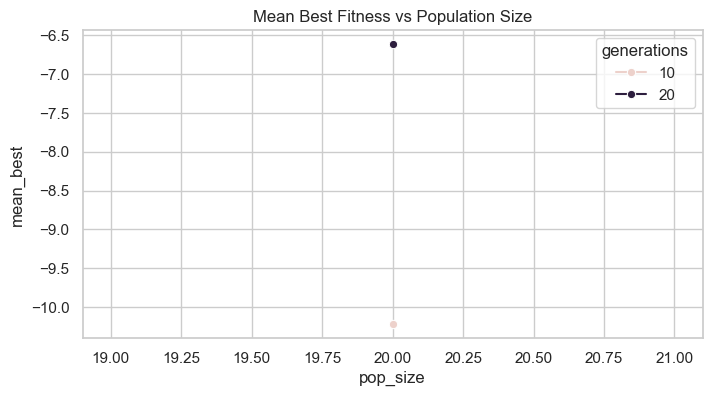

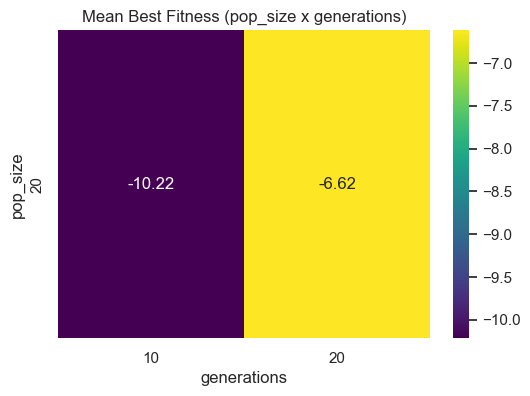

In [9]:
# Visualization: final metrics (line plots, heatmaps)
if not df_all.empty:
    plt.figure(figsize=(8,4))
    sns.lineplot(data=summary, x='pop_size', y='mean_best', hue='generations', marker='o')
    plt.title('Mean Best Fitness vs Population Size')
    plt.show()

    # Heatmap pivot
    pivot = summary.pivot(index='pop_size', columns='generations', values='mean_best')
    plt.figure(figsize=(6,4))
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='viridis')
    plt.title('Mean Best Fitness (pop_size x generations)')
    plt.show()
else:
    print('No aggregated results to plot.')

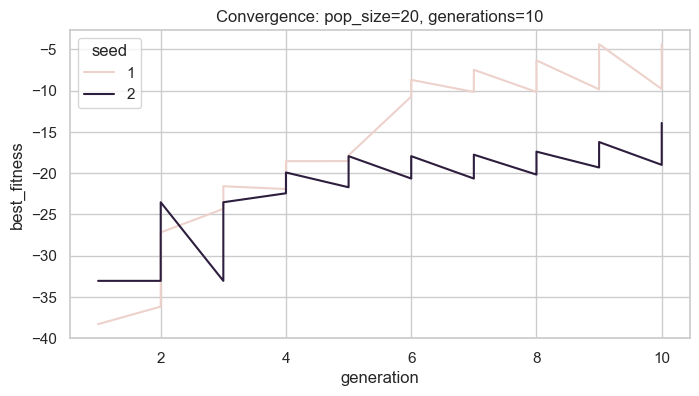

In [10]:
# Visualization: per-generation convergence curves
if not df_all.empty:
    long_rows = []
    for idx, row in df_all.iterrows():
        for h in row['history']:
            long_rows.append({
                'pop_size': row['pop_size'],
                'generations': row['generations'],
                'elitism': row['elitism'],
                'seed': row['seed'],
                'generation': h['generation'],
                'best_fitness': h['best_fitness']
            })
    df_long = pd.DataFrame(long_rows)

    # Select one parameter slice to plot
    selected = df_long[(df_long['pop_size']==20) & (df_long['generations']==10)]
    plt.figure(figsize=(8,4))
    sns.lineplot(data=selected, x='generation', y='best_fitness', hue='seed', estimator=None)
    plt.title('Convergence: pop_size=20, generations=10')
    plt.show()
else:
    print('No history data available for per-generation plots.')

In [11]:
# Reproducibility and seeding
# For deterministic experiments, use integer seeds and convert to JAX keys deterministically.
seed = 12345
key = jr.PRNGKey(seed)
res1 = adapter.run_once(key)
res2 = adapter.run_once(jr.PRNGKey(seed))
print('Re-run same seed gives identical best fitness:', res1['summary']['best_fitness'] == res2['summary']['best_fitness'])

print('\nNote: Parallel execution requires careful seed assignment per job to avoid collisions.')

Re-run same seed gives identical best fitness: True

Note: Parallel execution requires careful seed assignment per job to avoid collisions.


In [12]:
# Performance measurements and timings
# Measure a few runs
times = []
for s in [10,11,12]:
    t0 = time.perf_counter()
    _ = adapter.run_once(jr.PRNGKey(s))
    t1 = time.perf_counter()
    times.append(t1-t0)

print('Wall times (s):', times)
print('Average run time (s):', np.mean(times))
print('Approx throughput (runs/sec):', 1.0/np.mean(times))

Wall times (s): [0.16805700003169477, 0.10925783298444003, 0.1736836249474436]
Average run time (s): 0.1503328193211928
Approx throughput (runs/sec): 6.651907444531159


In [13]:
# Save / load sweep results
out_dir = Path('results/parameter_sweep/notebook_demo')
out_dir.mkdir(parents=True, exist_ok=True)

if not df_all.empty:
    # Save flat CSV (drop history for CSV simplicity)
    df_all_flat = df_all.drop(columns=['history']).copy()
    df_all_flat.to_csv(out_dir / 'sweep_results_flat.csv', index=False)

    # Prepare JSON-safe records, converting non-serializable objects to metadata
    def _to_native(v):
        # Convert numpy scalars to Python primitives
        if isinstance(v, np.generic):
            return v.item()
        return v

    def _serialize_value(v):
        v = _to_native(v)
        try:
            json.dumps(v)
            return v
        except TypeError:
            # Evaluator-like objects with a .config attribute
            if hasattr(v, 'config'):
                cfg = getattr(v, 'config')
                try:
                    cfg_dict = cfg.__dict__
                except Exception:
                    cfg_dict = str(cfg)
                return {'_class': v.__class__.__name__, 'config': cfg_dict}
            # Fallback: string representation
            return str(v)

    records = df_all.to_dict(orient='records')
    serial_records = []
    for rec in records:
        srec = {}
        for k, val in rec.items():
            if k == 'history':
                # History is already JSON-friendly (list of dicts with numeric values)
                srec[k] = val
            else:
                srec[k] = _serialize_value(val)
        serial_records.append(srec)

    with open(out_dir / 'sweep_results.json', 'w') as f:
        json.dump(serial_records, f, indent=2)

    print('Saved results to', out_dir)
else:
    print('No results to save.')

Saved results to results/parameter_sweep/notebook_demo


In [14]:
# Quick tests (demo style assertions) + debug types
# 1. genome_length alias
from malthusjax.operators.selection.tournament import TournamentSelection


adapter2 = build_engine(
    fitness_evaluator=sphere_eval,
    selection_op=sel,
    crossover_op=cross,
    mutation_op=mut,
    genome_type='real',
    pop_size=10,
    generations=5,
    genome_length=10,  # alias for genome_shape
)
assert hasattr(adapter2.genome_config, 'shape') and adapter2.genome_config.shape[0] == 10

# Debug: print operator types so we see unexpected types early
print('adapter2.selection type:', type(adapter2.genetic_engine.selection))
print('adapter2.crossover type:', type(adapter2.genetic_engine.crossover))
print('adapter2.mutation type:', type(adapter2.genetic_engine.mutation))

# 2. run_once keys
r = adapter2.run_once(jr.PRNGKey(1))
assert set(r.keys()) >= {'history', 'summary', 'timings'}
assert isinstance(r['summary']['final_generation'], int)

print('Quick assertions passed. For full unit tests, create pytest files in tests/ and run pytest.')

adapter2.selection type: <class 'malthusjax.operators.selection.tournament.TournamentSelection'>
adapter2.crossover type: <class 'malthusjax.operators.crossover.real.BlendCrossover'>
adapter2.mutation type: <class 'malthusjax.operators.mutation.real.GaussianMutation'>
Quick assertions passed. For full unit tests, create pytest files in tests/ and run pytest.


## Closing notes

- Results saved under `results/parameter_sweep/notebook_demo/`.
- To scale up: increase `pop_size`, `generations`, and `seeds`; consider running on a workstation or cluster and use parallel execution.
- Next steps: integrate `EvosaxAdapter` (see `docs/EVOSAX_ADAPTER_ROADMAP.md`) and add JIT-compiled `run_jit` for higher throughput.

Happy sweeping! 🎯